In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ruta al prompt en Drive
prompt_path = "/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/zero_shot_prompt.txt"

# Leer prompt base
with open(prompt_path, "r", encoding="utf-8") as f:
    base_prompt = f.read()

Mounted at /content/drive


In [ ]:
# Texto a clasificar
texto_a_clasificar = "Ayer fui al supermercado y compré pan y leche."

# Construir prompt final
full_prompt = base_prompt + texto_a_clasificar

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
model_id = "mistralai/Mistral-7B-Instruct-v0.2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [ ]:
def clasificar_nivel(texto):

# Definimos el prompt siguiendo el formato de Mistral
  prompt = f"{base_prompt}\n{texto} [/INST] Nivel:"
  inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

# Limitamos max_new_tokens a 3 o 4 porque solo queremos la etiqueta (ej. "B2")
  output = model.generate(**inputs, max_new_tokens=2, pad_token_id=tokenizer.eos_token_id)
  respuesta = tokenizer.decode(output[0], skip_special_tokens=True)

# Limpiamos la respuesta para quedarnos solo con lo después del [/INST]
  return respuesta.split("Nivel:")[-1].strip()

In [ ]:
# Ejemplo de uso
texto_ejemplo = "A pesar de las vicisitudes del sistema económico, la resiliencia social permitió mitigar el impacto."

print(clasificar_nivel(texto_ejemplo)) # Debería devolver C1 o C2

B2


In [ ]:
# Ejemplo de uso
texto_ejemplo = "mi gusta comer tapas. normalmente jugo al futbol con mis amigo"

print(clasificar_nivel(texto_ejemplo)) # Debería devolver A2

A2


In [ ]:
# Ejemplo de uso
texto_ejemplo = "Ayer vi a mi amigo y fuimos a cenar juntas"

print(clasificar_nivel(texto_ejemplo)) # Debería devolver A2

B2


In [ ]:
# Ejemplo de uso
texto_ejemplo = "Necesitamos que se pongan límites en el mercado de la vivienda"

print(clasificar_nivel(texto_ejemplo)) # Debería devolver B1

B1


In [ ]:
# Ejemplo de uso
texto_ejemplo = "Yo soy Loubna. Soy alta delgada."

print(clasificar_nivel(texto_ejemplo)) # Debería devolver A1

A1


### Proceso de clasificación


In [ ]:
import pandas as pd

In [ ]:
import sys
# Ruta al archivo CSV de entrada con los ejemplos
input_csv_path = "/content/drive/MyDrive/corpusELE_data/val_corpusELE.csv"

# Cargar el CSV en un DataFrame de pandas
try:
    df_examples = pd.read_csv(input_csv_path)
    print(f"CSV '{input_csv_path}' cargado exitosamente. Se han encontrado {len(df_examples)} ejemplos.")
    # Renombrar la columna 'label' del CSV a 'true_label' para preservarla
    if 'label' in df_examples.columns:
        df_examples.rename(columns={'label': 'true_label'}, inplace=True)
        print("Columna 'label' renombrada a 'true_label'.")
    display(df_examples.head())
except FileNotFoundError:
    print(f"Error: El archivo '{input_csv_path}' no se encontró. Por favor, verifica la ruta.")
    sys.exit(1)
except Exception as e:
    print(f"Error al cargar el CSV: {e}")
    sys.exit(1)

CSV '/content/drive/MyDrive/corpusELE_data/val_corpusELE.csv' cargado exitosamente. Se han encontrado 4679 ejemplos.
Columna 'label' renombrada a 'true_label'.


,id,text,true_label
0,24092,Así fueran los dias .,A2
1,3068,"Me dijo que el hombre no hablaba de bomba , si...",B1
2,1012,No es posible mantener un servicio con tantos ...,C1
3,43959,EL proximo año yo estoy piensando ir para Cuba...,A2
4,42573,Tuve un conversaciòn con su compañia durante e...,C1


In [ ]:
# Asegurarse de que hay una columna 'id', si no, crear una
if 'id' not in df_examples.columns:
    df_examples['id'] = range(1, len(df_examples) + 1)

# Aplicar la función de clasificación a un subconjunto de textos (ej. las primeras 50 filas)
print("Clasificando textos (primeras 50 filas)...")
df_examples_subset = df_examples.head(50).copy()
df_examples_subset['predicted_label'] = df_examples_subset['text'].apply(clasificar_nivel)

print("Clasificación completada para el subconjunto. Primeros resultados:")
display(df_examples_subset[['id', 'text', 'true_label', 'predicted_label']].head())

# Calcular la precisión para el subconjunto
if 'true_label' in df_examples_subset.columns:
    accuracy = (df_examples_subset['true_label'] == df_examples_subset['predicted_label']).mean()
    print(f"\nPrecisión del modelo en el subconjunto: {accuracy:.2f}")
else:
    print("No se encontró la columna 'true_label' para calcular la precisión en el subconjunto.")

Clasificando textos (primeras 50 filas)...
Clasificación completada para el subconjunto. Primeros resultados:


,id,text,true_label,predicted_label
0,24092,Así fueran los dias .,A2,B1
1,3068,"Me dijo que el hombre no hablaba de bomba , si...",B1,B1
2,1012,No es posible mantener un servicio con tantos ...,C1,B1
3,43959,EL proximo año yo estoy piensando ir para Cuba...,A2,A2
4,42573,Tuve un conversaciòn con su compañia durante e...,C1,B1



Precisión del modelo en el subconjunto: 0.28


### Análisis de Resultados

Finalmente, guardaremos los resultados en un nuevo archivo CSV (`submissionMistral.csv`).

Clasificando todos los textos de df_examples...
Clasificación completada para df_examples.

Reporte de Clasificación:

              precision    recall  f1-score   support

          A1       0.48      0.42      0.45      1214
          A2       0.35      0.23      0.28      1400
          B1       0.24      0.45      0.31      1083
          B2       0.25      0.25      0.25       682
          C1       0.43      0.01      0.02       300
       No se       0.00      0.00      0.00         0

    accuracy                           0.32      4679
   macro avg       0.29      0.23      0.22      4679
weighted avg       0.35      0.32      0.31      4679



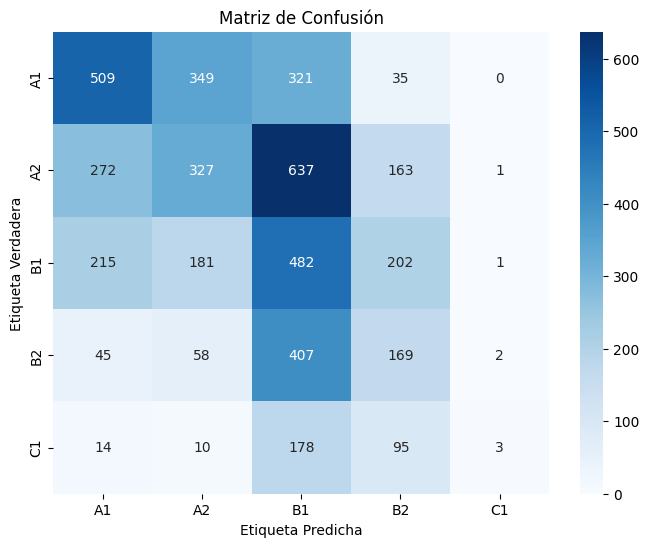

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Aplicar la función de clasificación a todos los textos en df_examples
print("Clasificando todos los textos de df_examples...")
df_examples['predicted_label'] = df_examples['text'].apply(clasificar_nivel)
print("Clasificación completada para df_examples.")

# Asegurarse de que las etiquetas son del mismo tipo (string)
df_examples['true_label'] = df_examples['true_label'].astype(str)
df_examples['predicted_label'] = df_examples['predicted_label'].astype(str)

# Eliminar filas donde predicted_label es NaN o vacío si existen
df_examples_cleaned = df_examples.dropna(subset=['predicted_label'])

# Generar el reporte de clasificación
print("\nReporte de Clasificación:\n")
print(classification_report(df_examples_cleaned['true_label'], df_examples_cleaned['predicted_label'], zero_division=0))

# Generar la matriz de confusión
conf_mat = confusion_matrix(df_examples_cleaned['true_label'], df_examples_cleaned['predicted_label'], labels=sorted(df_examples_cleaned['true_label'].unique()))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(df_examples_cleaned['true_label'].unique()),
            yticklabels=sorted(df_examples_cleaned['true_label'].unique()))
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

Predecimos los textos de test

In [ ]:
import pandas as pd

# Definir la ruta del test
test_path = "/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/test.csv"

# Cargar el CSV de test en un DataFrame de pandas
try:
    df_test = pd.read_csv(test_path)
    print(f"CSV de test '{test_path}' cargado exitosamente. Se han encontrado {len(df_test)} ejemplos.")
    # Asegurarse de que hay una columna 'id', si no, crear una
    if 'id' not in df_test.columns:
        df_test['id'] = range(1, len(df_test) + 1)
except FileNotFoundError:
    print(f"Error: El archivo '{test_path}' no se encontró. Por favor, verifica la ruta.")
    sys.exit(1)
except Exception as e:
    print(f"Error al cargar el CSV de test: {e}")
    sys.exit(1)

# Definir la ruta del archivo CSV de salida para la submission
output_csv_path = "/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/predictionsMistral.csv"

# Aplicar la función de clasificación a todos los textos en df_test
print("Clasificando todos los textos de test...")
df_test['label'] = df_test['text'].apply(clasificar_nivel)

# Guardar el DataFrame con 'id' y 'label'
df_to_save = df_test[['id', 'label']].copy()
df_to_save.to_csv(output_csv_path, index=False)

print(f"Resultados guardados exitosamente en '{output_csv_path}'")
print("Contenido del archivo de salida (primeras 5 líneas):")
with open(output_csv_path, 'r') as f:
    for _ in range(min(5, len(df_to_save) + 1)): # Mostrar las primeras 5 líneas o menos si el archivo es pequeño
        print(f.readline(), end='')


CSV de test '/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/test.csv' cargado exitosamente. Se han encontrado 316 ejemplos.
Clasificando todos los textos de test...
Resultados guardados exitosamente en '/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/predictionsMistral.csv'
Contenido del archivo de salida (primeras 5 líneas):
id,label
0,A2
1,B2
2,A2
3,A2
